# Analysis

Downloading data using the `mlcroissant` library

In [173]:
import mlcroissant as mlc
import pandas as pd
import matplotlib.pyplot as plt

# downloads the dataset
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis/croissant/download')

  -  [Metadata(Twitter Sentiment Analysis)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


This is the raw data that is produced straight from the dataset

In [174]:
record_sets = croissant_dataset.metadata.record_sets
print(record_sets) # we have two datasets: "twitter_training" and "twitter_validation"

df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
df.head()

[RecordSet(uuid="twitter_training.csv"), RecordSet(uuid="twitter_validation.csv")]


,twitter_training.csv/2401,twitter_training.csv/Borderlands,twitter_training.csv/Positive,twitter_training.csv/im+getting+on+borderlands+and+i+will+murder+you+all+%2C
0,2401,b'Borderlands',b'Positive',b'I am coming to the borders and I will kill y...
1,2401,b'Borderlands',b'Positive',b'im getting on borderlands and i will kill yo...
2,2401,b'Borderlands',b'Positive',b'im coming on borderlands and i will murder y...
3,2401,b'Borderlands',b'Positive',b'im getting on borderlands 2 and i will murde...
4,2401,b'Borderlands',b'Positive',b'im getting into borderlands and i can murder...


## Initial data analysis

Right now, looks like we have 4 available columns:
- ID??/Class id??? (unsure, not required)
- Company/Genre/Username (again, unsure. the dataset doesn't give a lot of information)
- Sentiment, classified as either `Positive`, `Negative`, `Neutral` or `Irrelevant`. In this dataset, it was recommended that `Irrelevant = Neutral`. Each of the classifications are what they mean, no need to explain. 
- The text content of the tweet. 

To use this model, we only need two pieces of data: 
- Sentiment
- Text content (tokenised)

The others are not required/idk what they do/they probably won't help that much

# Quick cleanup of data

Some of the columns are not necessary at all. I will purge them and preppare for preprocessing

Firstly, lets remove the unnecessary columns we mentioned previously. Since this dataset is poorly formatted, we will have to remove it with these specific keywords. 

In [175]:
df = df.drop(columns=['twitter_training.csv/2401', 'twitter_training.csv/Borderlands'])

Next, we drop the first row for the same reason

In [176]:
df = df.drop(index=0).reset_index(drop=True)

I add proper generic naming to the columns

In [177]:
df.columns = ['Sentiment', 'Text Content']

Now, we need to convert the text content as bytes to be able to modify the string content. 

In [178]:
df['Sentiment'] = df['Sentiment'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df['Text Content'] = df['Text Content'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [179]:
df.head()

,Sentiment,Text Content
0,Positive,im getting on borderlands and i will kill you ...
1,Positive,im coming on borderlands and i will murder you...
2,Positive,im getting on borderlands 2 and i will murder ...
3,Positive,im getting into borderlands and i can murder y...
4,Positive,So I spent a few hours making something for fu...


Checking the head, we see a lot of positive borderlands content. I want to see other data, so I will reshuffle the data. It does not make a difference in training, but it makes analysis a lot more better.  

In [180]:
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,Sentiment,Text Content
0,Negative,Though all this is great local news for. bit. ...
1,Neutral,Rumor has has it Jensens black spatulas aren a...
2,Irrelevant,A spell for Battlefield 4 player DearonVX has ...
3,Neutral,Just bought @ GhostRecon _ UK because it is se...
4,Neutral,Microsoft Now partnered With Trans-Monsanto Fr...


Now it's more nicer!

We need to remove any tweets/text that might be bad (NaN or empty) to remove the noise within the content

In [181]:
df = df[
    ~(
        df["Text Content"].fillna("").str.strip().eq("")
    )
].reset_index(drop=True)
df = df[df['Text Content'].str.strip().str.len() > 0].reset_index(drop=True)

Remove any duplicate data

In [182]:
print(f"before: {len(df)}")
print(f"duplicated: {df.duplicated(subset='Text Content').sum()}")

df = df.drop_duplicates(subset='Text Content').reset_index(drop=True)

print(f"after: {len(df)}")

before: 73822
duplicated: 4334
after: 69488


There may be some text that contains `<unk>`, which means "Unknown Token". Likely happened during parsing from the dataset creator. It's best to remove them. 

In [183]:
df['Text Content'] = df['Text Content'].str.replace('<unk>', '', regex=False)
df['Text Content'] = df['Text Content'].str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['Text Content'].str.strip().str.len() > 0].reset_index(drop=True)

Now let's see it in its glory!

In [184]:
df.head()

,Sentiment,Text Content
0,Negative,Though all this is great local news for. bit. ...
1,Neutral,Rumor has has it Jensens black spatulas aren a...
2,Irrelevant,A spell for Battlefield 4 player DearonVX has ...
3,Neutral,Just bought @ GhostRecon _ UK because it is se...
4,Neutral,Microsoft Now partnered With Trans-Monsanto Fr...


## Describing the dataset

In [185]:
df.describe()

,Sentiment,Text Content
count,69487,69487
unique,4,69075
top,Negative,.
freq,21170,7


Our dataset has 73822 rows of twitter tweets, with 4 different sentiments. 

The sentiments are Positive, Negative, Neutral and Irrelevant. The creator of the dataset has stated to merge neutral and irrelevant together, or to remove irrelevant altogether. 

The top text content is completely random (as the dataset is shuffled), so there is no useful information from analysing this. 

The frequency is highly leaned towards a more negative side. This is typical to see within twitter (as twitter is stereotypically a place full of rantings and a place to put out anger). 

## Sentiment counts

In [186]:
print(df['Sentiment'].value_counts())

Sentiment
Negative      21170
Positive      19058
Neutral       17041
Irrelevant    12218
Name: count, dtype: int64


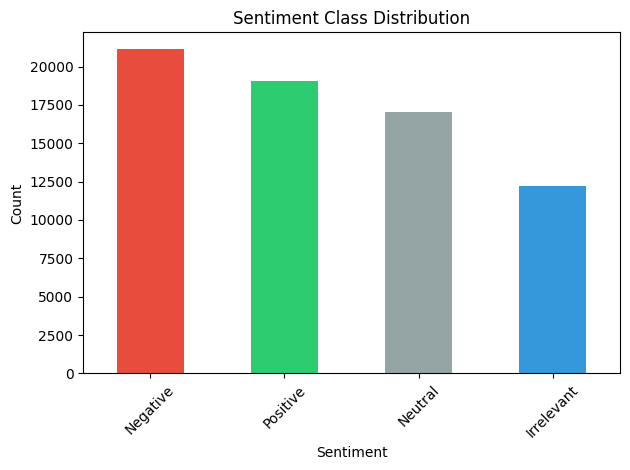

In [187]:
# disclaimer: block gen by ai
df['Sentiment'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71', '#95a5a6', '#3498db'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tweet length

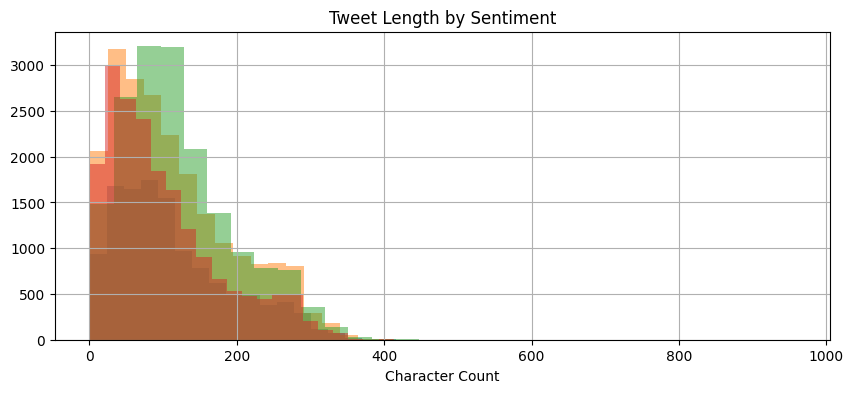

              count        mean        std  min   25%    50%    75%    max
Sentiment                                                                 
Irrelevant  12218.0  113.480193  77.786497  1.0  54.0   94.0  157.0  692.0
Negative    21170.0  115.142371  80.780864  1.0  50.0   95.0  165.0  727.0
Neutral     17041.0  122.130626  75.447649  1.0  66.0  108.0  164.0  957.0
Positive    19058.0  100.479326  76.521063  1.0  41.0   79.0  139.0  619.0


In [188]:
# disclaimer: block gen by ai
df['tweet_length'] = df['Text Content'].apply(len)

df.groupby('Sentiment')['tweet_length'].hist(alpha=0.5, bins=30, figsize=(10, 4))
plt.title('Tweet Length by Sentiment')
plt.xlabel('Character Count')
plt.show()

# Summary stats per class
print(df.groupby('Sentiment')['tweet_length'].describe())

Most tweets have a word count of 95-118 words. 
- Neutral tweets are on average about 111 words. Such tweets tend to be more descriptive/factual. 
- Positive tweets are short as they only contain words of affirmation and gratitude. 

A high standard deviation suggests that it cannot be used as a predictor, however it can potentially be used as a feature to sentiment. 

## Most common words

We can locate the most common words by using a library called `wordcloud`, which (as the name suggests) creates a cloud of data containing the words within the dataset, and its size increases for the word count. 

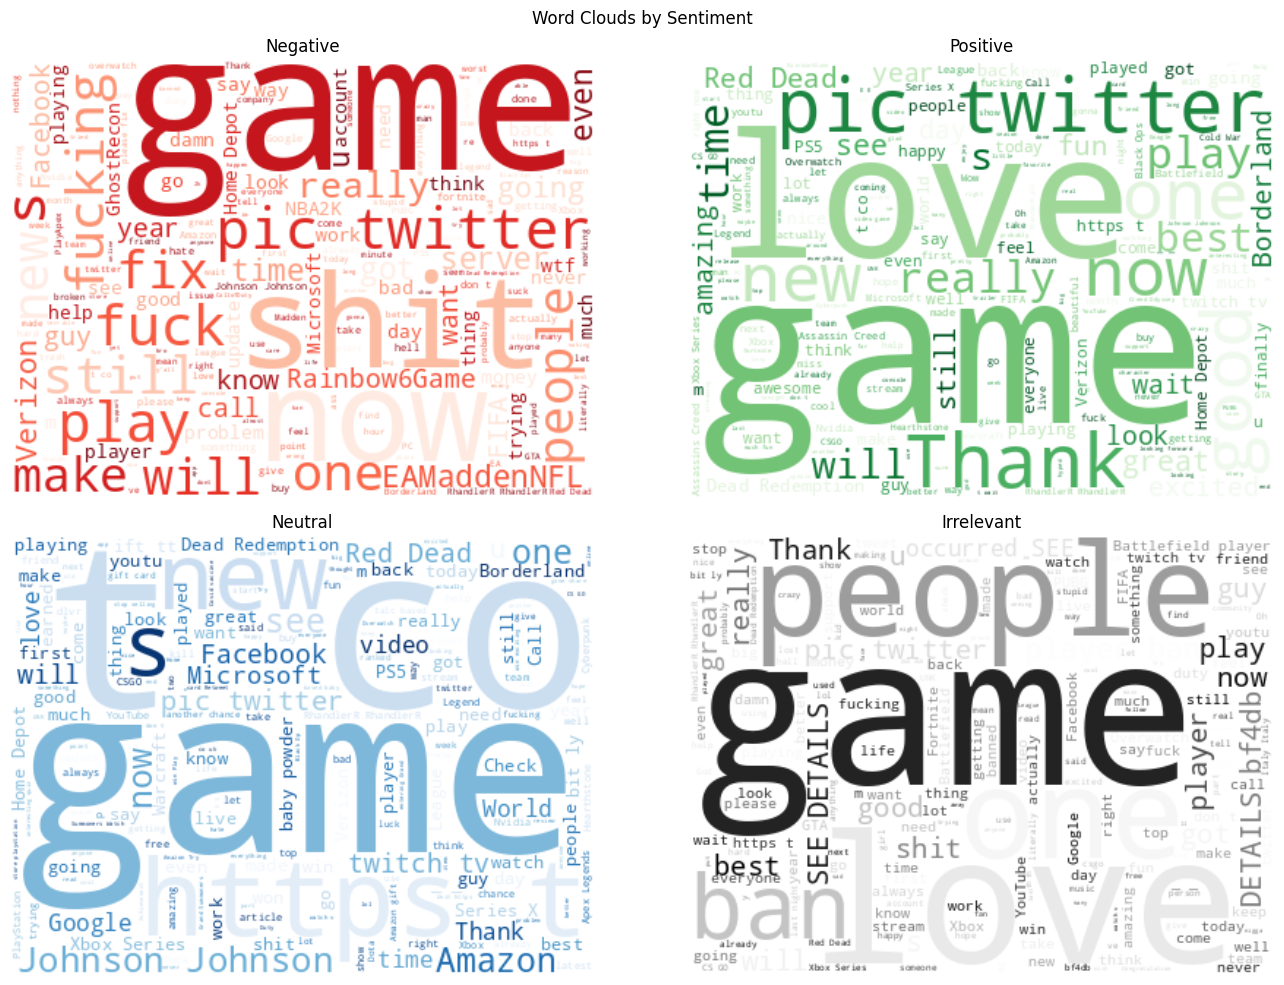

In [189]:
# disclaimer: block gen by ai
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colours = {'Negative': 'Reds', 'Positive': 'Greens', 
            'Neutral': 'Blues', 'Irrelevant': 'Greys'}

for ax, (sentiment, colour) in zip(axes.flatten(), colours.items()):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Text Content'])
    wc = WordCloud(width=400, height=300, 
                    colormap=colour, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment)
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment')
plt.tight_layout()
plt.show()

By the looks of it: 
- negative (the largest dataset) contains more swear words and profanity. 
- positive has the word "love" to be pretty large. 
- neutral may be mainly links and some "Thank you". A large mention of "Johnson" is related to the company "Johnson&Johnson". 
- irrelevant also contains "love", however the context of the text may not be related to the dataset. 

All sentiments heavily contain mentions of "game", which may insist the dataset is related to tweets within gaming. It may also contain be corporate related, since there is reference to "Johnson&Johnson". 

The dataset (when picked) did not mention it being about gaming though and looking through the dataset, it is just a general twitter feed. 

## Describing the data

In [190]:
df.describe()

,tweet_length
count,69487.000000
mean,112.542317
std,78.219944
min,1.000000
25%,51.000000
50%,95.000000
75%,156.000000
max,957.000000


- Mean -> pretty average considering a tweet
- std -> high variation suggets there is large variation between tweets. 
- min -> 1 word
- max -> there may be some spammers that just spam text into their tweets. the dataset seems to have pulled it in. 

In [191]:
# block gen by ai
print(f"Total rows:     {len(df)}")
print(f"Duplicates:     {df.duplicated(subset='Text Content').sum()}")
print(f"Unique tweets:  {df['Text Content'].nunique()}")
print(f"Duplicate rate: {df.duplicated(subset='Text Content').sum() / len(df) * 100:.2f}%")

Total rows:     69487
Duplicates:     412
Unique tweets:  69075
Duplicate rate: 0.59%


# Export

After our initial analysis, let's export this for the next stage. 

In [192]:
import os
try:
    os.mkdir("csv")
except: pass
df.to_csv("csv/all_data.csv")